In [1]:
import csv

# Read CSV file
with open("raw/outagesNYISO.csv") as file:
    csv_reader = csv.DictReader(file)
    data = list(csv_reader)

In [2]:
# based on paper:
# outages: 45178, automatic: 9600, planned: 35578
total = len(data)
auto = len([row for row in data if row["OutageType"] == "Auto"])
planned = len([row for row in data if row["OutageType"] == "Planned"])

print(f"Total outages: {total:,} | Automatic: {auto:,} | Planned: {planned:,}")

Total outages: 45,178 | Automatic: 9,600 | Planned: 35,578


In [3]:
data[0]

{'OutageID': '2',
 'PTID': '26007',
 'Name': 'GOWANUSA-GREENWD__138_42G24',
 'OutDatetime': 'DateObject[{2008, 11, 1, 0, 12, 0.}, "Instant", "Gregorian", "America/New_York"]',
 'MinTimeStamp': 'DateObject[{2008, 11, 1, 0, 17, 18.}, "Instant", "Gregorian", "America/New_York"]',
 'MaxTimeStamp': 'DateObject[{2008, 11, 2, 23, 57, 19.}, "Instant", "Gregorian", "America/New_York"]',
 'NearestSCtime': 'DateObject[{2008, 11, 1, 0, 12, 17.}, "Instant", "Gregorian", "America/New_York"]',
 'TimeDifferencefromScheduled': '0.2833333333333333',
 'OutageType': 'Planned',
 'DurationBAD': '2865.3166666666666',
 'LineNameOLD': '{"GOWANUSA", "GREENWD", 1}',
 'Voltage': '138',
 'BusNames': '{"GOWANUSA", "GREENWD"}',
 'UnitNumber': '1',
 'LineName': '{"GOWANUSA", "GREENWD", 1}',
 'OutAbstime': '3434501520',
 'TimeZone': 'EPT'}

In [4]:
import re
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo


PATTERN = re.compile(
    r"^DateObject\[\{\s*"
    r"(?P<year>-?\d+)\s*,\s*"
    r"(?P<month>\d+)\s*,\s*"
    r"(?P<day>\d+)\s*,\s*"
    r"(?P<hour>\d+)\s*,\s*"
    r"(?P<minute>\d+)\s*,\s*"
    r"(?P<second>\d+(?:\.\d*)?)\s*"
    r'\}\s*,\s*"[^"]*"\s*,\s*"[^"]*"\s*,\s*"(?P<tz>[^"]+)"\s*\]$'
)


def parse_dateobject(s: str) -> datetime:
    m = PATTERN.match(s.strip())
    if not m:
        raise ValueError(f"Invalid DateObject format: {s}")

    year = int(m.group("year"))
    month = int(m.group("month"))
    day = int(m.group("day"))
    hour = int(m.group("hour"))
    minute = int(m.group("minute"))
    sec_float = float(m.group("second"))  # handles 0. / 18. / 12.345
    tz = ZoneInfo(m.group("tz"))

    sec_int = int(sec_float)
    micro = int(round((sec_float - sec_int) * 1_000_000))
    if micro == 1_000_000:  # rounding edge case
        sec_int += 1
        micro = 0

    dt = datetime(year, month, day, hour, minute, 0, 0, tzinfo=tz)
    dt += timedelta(seconds=sec_int, microseconds=micro)
    return dt

In [5]:
# parse and convert data attributes in pythonic format
for datum in data:
    datum["OutDatetime"] = parse_dateobject(datum["OutDatetime"])
    datum["MinTimeStamp"] = parse_dateobject(datum["MinTimeStamp"])
    datum["MaxTimeStamp"] = parse_dateobject(datum["MaxTimeStamp"])
    datum["BusNames"] = eval(datum["BusNames"])

data = sorted(data, key=lambda d: d["OutDatetime"])

In [6]:
t0 = data[0]["OutDatetime"]
t1 = data[1]["OutDatetime"]
t0, t1, t1 - t0

(datetime.datetime(2008, 11, 1, 0, 12, tzinfo=zoneinfo.ZoneInfo(key='America/New_York')),
 datetime.datetime(2008, 11, 1, 1, 27, tzinfo=zoneinfo.ZoneInfo(key='America/New_York')),
 datetime.timedelta(seconds=4500))

In [7]:
# second is zero for all outages
[datum for datum in data if datum["OutDatetime"].second > 0]

[]

In [8]:
data_auto = [datum for datum in data if datum["OutageType"] == "Auto"]

In [9]:
# Form cascading failures based on time thresholds
# TIME THRESHOLDS (in seconds)
SAME_GENERATION_THRESHOLD = 60 * 1
SAME_CASCADING_THRESHOLD = 3600

cascading_failures = []
current_cascade = [[data_auto[0]]]
for datum in data_auto[1:]:
    last_out_datetime = current_cascade[-1][-1]["OutDatetime"]
    current_out_datetime = datum["OutDatetime"]
    time_diff = (current_out_datetime - last_out_datetime).total_seconds()
    if time_diff <= SAME_GENERATION_THRESHOLD:
        current_cascade[-1].append(datum)
        continue
    if time_diff <= SAME_CASCADING_THRESHOLD:
        current_cascade.append([datum])
        continue
    if time_diff > SAME_CASCADING_THRESHOLD:
        cascading_failures.append(current_cascade)
        current_cascade = [[datum]]
        continue

In [10]:
generation_sizes = [len(cascading_failure) for cascading_failure in cascading_failures]
cascading_failure_sizes = [
    sum(len(gen) for gen in cascading_failure)
    for cascading_failure in cascading_failures
]
initial_failure_sizes = [
    len(cascading_failure[0]) for cascading_failure in cascading_failures
]

In [11]:
# based on paper:
# there are 6687 cascading failures
len(cascading_failures)

6151

In [12]:
# based on paper:
# 84% of cascades have only single generation
single_gen_cascades = [c for c in cascading_failures if len(c) == 1]
len(single_gen_cascades) / len(cascading_failures)

0.8397008616485124

In [13]:
# based on paper:
# 66% of cascades have only one outage
single_outage_cascades = [c for c in single_gen_cascades if len(c[0]) == 1]
len(single_outage_cascades) / len(cascading_failures)

0.6615184522841814

In [14]:
# based on paper:
# number of unique buses: 1192 (total), 1139 bit connected component
bus_set_auto = set()
for datum in data_auto:
    bus_set_auto.update(datum["BusNames"])
print(len(bus_set_auto))

bus_set = set()
for datum in data:
    bus_set.update(datum["BusNames"])
print(len(bus_set))

1034
1139


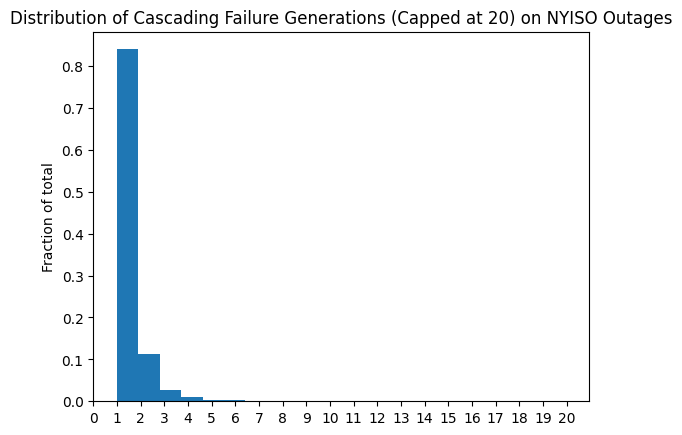

In [15]:
import matplotlib.pyplot as plt

MAX_GEN = 20
values = [min(i, MAX_GEN) for i in generation_sizes]
n = len(generation_sizes)

plt.hist(values, weights=[1 / n] * n, bins=MAX_GEN + 1)
plt.ylabel("Fraction of total")
plt.xticks(range(0, MAX_GEN + 1))
plt.title(
    f"Distribution of Cascading Failure Generations (Capped at {MAX_GEN}) on NYISO Outages"
)
plt.show()

In [16]:
from typing import Optional

import numpy as np
import powerlaw


def plot_log_log(
    size_list: list[int],
    xmin: Optional[int] = None,
    xmax: Optional[int] = None,
    dpi: Optional[int] = 100,
):
    """Plot CCDF and fit a powerlaw distribution line to the points

    :param size_list: list of initial failure size, cascading failure size, cascading generations, etc.
    """
    fig, ax = plt.subplots(dpi=dpi)

    # plot log-log CCDF
    n = len(size_list)
    values, counts = np.unique(size_list, return_counts=True)
    order = np.argsort(values)
    values = values[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / n
    ax.loglog(values, ccdf, marker="o", linestyle="none")

    # fit a line
    fit = powerlaw.Fit(
        size_list,
        discrete=True,
        verbose=False,
        survival=True,
        xmin=xmin,
        xmax=xmax,
    )
    print("alpha:", fit.power_law.alpha)
    print("xmin :", fit.power_law.xmin)
    fit.power_law.plot_pdf(ax=ax, linestyle="--", label="Power-law fit")

    return ax

alpha: 3.2770865660782715
xmin : 3.0


<Axes: >

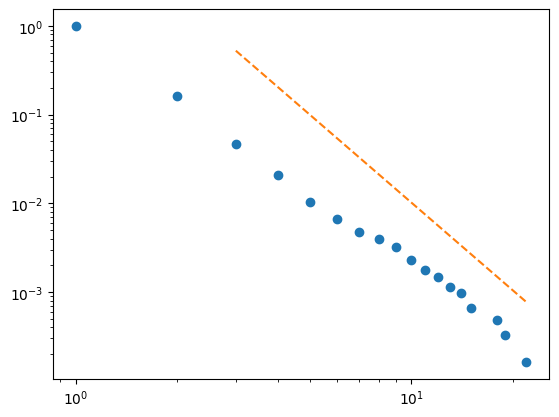

In [17]:
plot_log_log(generation_sizes)

alpha: 3.417258223133139
xmin : 4.0


<Axes: >

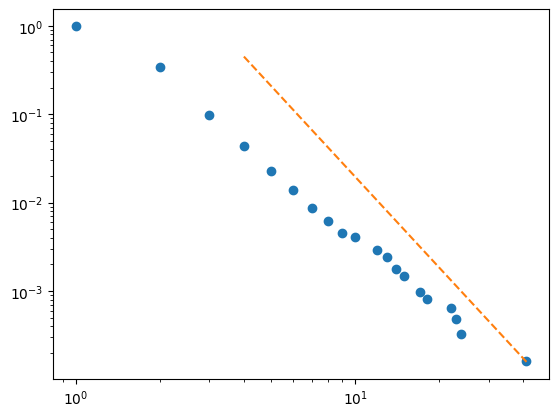

In [18]:
plot_log_log(cascading_failure_sizes)

alpha: 4.879805393898311
xmin : 4.0


<Axes: >

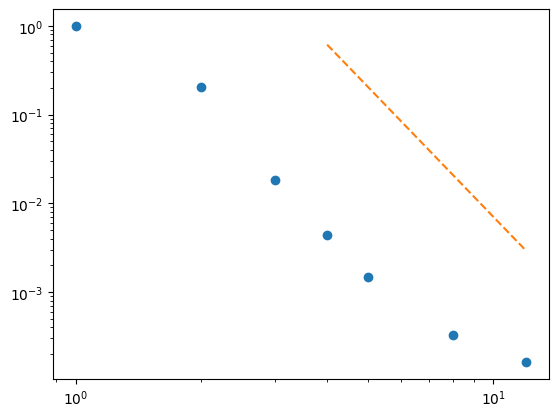

In [19]:
plot_log_log(initial_failure_sizes)

# How many times each PTID is seen in the dataset?

Number of Part IDs: 1774


(array([0.83970086, 0.11364006, 0.        , 0.02601203, 0.01024224,
        0.01040481]),
 array([1.        , 1.66666667, 2.33333333, 3.        , 3.66666667,
        4.33333333, 5.        ]),
 <BarContainer object of 6 artists>)

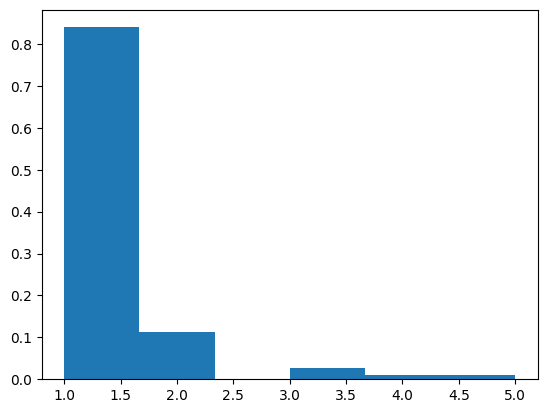

In [20]:
from collections import Counter

ptid_list = [datum["PTID"] for datum in data]
ptid_set = set(ptid_list)
print(f"Number of Part IDs: {len(ptid_set)}")
ptid_counts = Counter(ptid_list)
ptid_values = list(ptid_counts.values())

MAX = 5
n = len(generation_sizes)
plt.hist([min(i, MAX) for i in generation_sizes], bins=MAX + 1, weights=[1 / n] * n)

Most of the appeared one or twice in the whole dataset. It reduces the data usability.

# Check graph connectivity

In [ ]:
import igraph

bus_name_to_index = {bus_name: i for i, bus_name in enumerate(sorted(list(bus_set)))}
n = len(bus_name_to_index)
g = igraph.Graph(n=len(bus_name_to_index), directed=False)

edge_set = set()
for datum in data:
    b1, b2 = sorted(datum["BusNames"])
    b1_index, b2_index = bus_name_to_index[b1], bus_name_to_index[b2]
    edge_set.add((b1_index, b2_index))
g.add_edges(list(edge_set))

print(g.is_connected())

True
